
### References

* https://github.com/llnl/Wintap-Analytics/tree/main/2025-acme4-explore
* https://gdo168.llnl.gov/
* https://gdo168.llnl.gov/data/newdocs/datadict/
  

In [1]:
%%time
import io
import logging as lg
import numpy as np
import os
import pandas as pd
import re
from collections import Counter
import warnings
import pickle
import gzip

# Modelling
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, auc, classification_report, roc_auc_score, f1_score
from sklearn.metrics import adjusted_mutual_info_score as AMI
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
import random 

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
import igraph as ig
import partition_igraph
import umap

# utility functions and matching algorithm
import process_trees as pt


CPU times: user 12.8 s, sys: 419 ms, total: 13.2 s
Wall time: 7.36 s


In [2]:
## load df_trees and Trees
with gzip.open('Data/acme4_process_trees_and_df.pkl.gz', 'rb') as fp:
   Trees, df_trees =  pickle.load(fp)


In [3]:
## load embeddings
with gzip.open('Data/acme4_process_num_features_embedding_ecdf.pkl.gz', 'rb') as fp:
    Embedding_ecdf = pickle.load(fp)


# Temporal motifs

We consider temporal rooted subtrees of size up to 4 for each process tree. The temporal aspect comes from the cnstraint that each new node added to the motif must not have a timestamp is the past of the current nodes in the motif.

There is only one motif of size 2: root --> v with t(root) <= t(v)

There are two motifs of size 3: root --> v1 --> v2 and v1 <-- root --> v2, with t(root) <= t(v1) <= t(v2) 

There are six motifs of size 4 which we refer to as: 
* star (depth 1)
* line (depth 3)
* balanced (depth 2, symmetric)
and 3 types of imbalanced trees (depth 2, non-symmetric).
We use labels:
* bf_left (breadth first): v1 and v2 at depth 1, v3 attached to v1
* bf_right (breadth first): v1 and v2 at depth 1, v3 attached to v2
* df (depth first): v1 and v3 at depth 1, v2 attached to v1

It is easy to see that the number of motifs with $n$ nodes is $(n-1)!$ by adding the nodes one by one.


In [4]:
df_trees.head(10)

,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers
0,0,2,ssm-agent-worker.exe,15904,3,15889,0,0,0,15,"[1, 15789, 114]",0
1,0,6,svchost.exe,769,3,761,0,0,0,3,"[1, 759, 9]",0
2,0,39,ssm-document-worker.exe,4,2,3,0,0,0,1,"[1, 3]",0
3,0,52,svchost.exe,24,2,23,0,0,0,1,"[1, 23]",0
4,0,56,services.exe,22933,6,21039,0,0,0,162,"[1, 2270, 3776, 16534, 335, 17]",0
5,0,63,svchost.exe,2728,4,2036,0,0,0,115,"[1, 1838, 720, 169]",0
6,0,129,128.0.6613.138_128.0.6613.137_chrome_updater.exe,7,4,3,0,0,0,2,"[1, 2, 3, 1]",0
7,0,130,setup.exe,4,3,2,0,0,0,1,"[1, 2, 1]",0
8,0,141,ngentask.exe,4,2,3,0,0,0,1,"[1, 3]",0
9,0,214,ngentask.exe,4,2,3,0,0,0,1,"[1, 3]",0


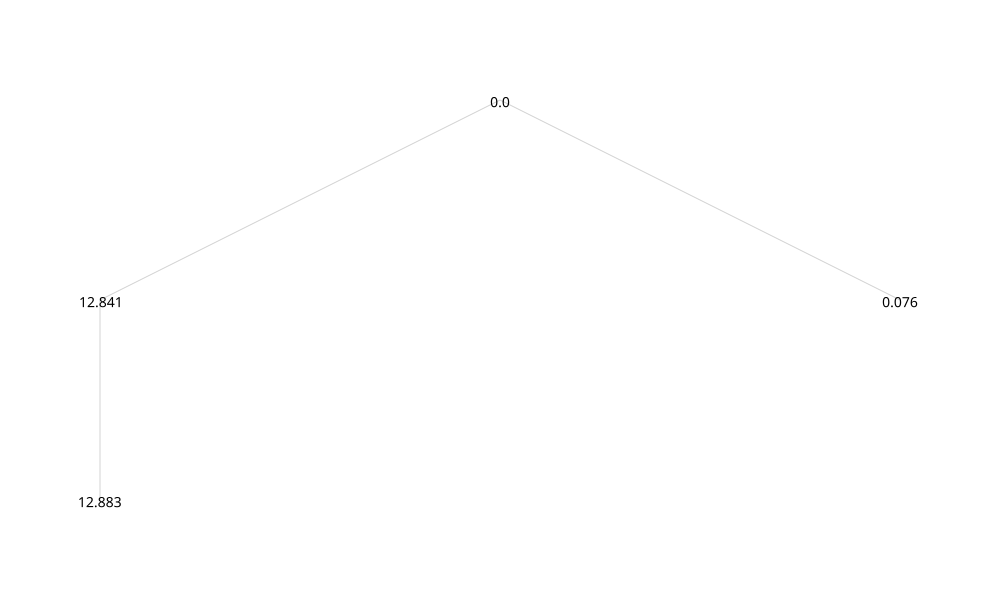

In [5]:
## example - temporal info
g = pt.get_bfs_subtree(Trees, 0, 130)
m = min(g.vs['time'])
g.vs['t'] = [str(round(i-m,3)) for i in g.vs['time']]
ig.plot(g, layout=g['ly'],  bbox=(1000,600), margin=100,  vertex_size=0, edge_color='lightgrey', edge_arrow_size=0, vertex_label=g.vs['t'])


In [6]:
## Based on algorithm MoSS (Molecular Substructure Miner) aka ESU (Enumerate Subgraphs), Wernicke (2006).
def get_rooted_subtrees(graph, root_node, max_size=4):
    """
    Finds all subtrees of a python-igraph Tree rooted at a specific node up to max_size.
    Returns a list of lists, where each list contains the vertex IDs of a subtree.
    """
    # 1. Convert the undirected igraph tree into a directed children dictionary from root
    children = {v.index: [] for v in graph.vs}
    visited = {root_node}
    queue = [root_node]
    
    while queue:
        curr = queue.pop(0)
        # Use graph.neighbors() for rapid igraph lookup
        for neighbor in graph.neighbors(curr):
            if neighbor not in visited:
                visited.add(neighbor)
                children[curr].append(neighbor)
                queue.append(neighbor)

    results = []

    # 2. Backtracking function using a strict frontier ordering to avoid duplicate subtrees
    def expand(current_nodes, frontier):
        results.append(list(current_nodes))
        
        if len(current_nodes) == max_size:
            return
            
        for i, next_node in enumerate(frontier):
            # Form a new frontier by skipping spent options and adding new valid children
            new_frontier = frontier[i+1:] + children[next_node]
            expand(current_nodes | {next_node}, new_frontier)

    # 3. Initialize the expansion with the root node and its immediate children
    initial_frontier = children[root_node]
    expand({root_node}, initial_frontier)
    
    return results

### Get motifs - up to size 4

In [7]:
## swap "root" as the root process - used for classification experiment
def swap_root(x):
    parts = x.split('::',1)
    if len(parts)>1:
        return "root::"+parts[1]
    else:
        return x

def get_motifs(Trees, df_trees, max_tree_size=10, max_motif_size=4):
    L = []
    if max_motif_size>4:
        max_motif_size=4
    for (t,r,s,p) in zip(df_trees.tree, df_trees.root, df_trees.nodes, df_trees.process):
        if s<= max_tree_size:
            g = pt.get_bfs_subtree(Trees, t, r)
            subtrees = get_rooted_subtrees(g, 0, max_motif_size)
            for st in subtrees:
                ## build small subtree
                sg = g.subgraph(st)
                sg = sg.permute_vertices(np.argsort(sg.vs['time']))
                dst = sg.distances(0)[0]
                ## chack validity of timestamps    
                is_valid = all(isinstance(x,(int,float)) for x in sg.vs['time'])
                if not is_valid:
                    continue

                ## size 4 motifs                            
                if len(st)==4:
                    pr = sg.vs[0]['process']+'::'+sg.vs[1]['process']+'::'+sg.vs[2]['process']+'::'+sg.vs[3]['process']
                    tm = sg.vs[3]['time'] - sg.vs[0]['time']
                    
                    if (dst[2]==1) and (dst[3]==1):
                        cl = 'star'
                    elif (dst[2]==2) and (dst[3]==3):
                        cl = 'line'
                    elif (dst[2]==2) and (dst[3]==2):
                        cl = 'balanced'
                    elif (dst[2]==1) and (dst[3]==2):
                        if sg.get_eid(1, 3, error=False) != -1:
                            cl = 'bf_left'
                        elif sg.get_eid(2, 3,error=False) != -1:
                            cl = 'bf_right'
                        else:
                            print('error')
                    elif (dst[2]==2) and (dst[3]==1):
                        cl = 'df'

                ## size 2 motif        
                elif len(st)==2:
                    pr = sg.vs[0]['process']+'::'+sg.vs[1]['process']
                    tm = sg.vs[1]['time'] - sg.vs[0]['time']
                    cl = 'edge'

                ## size 3 motifs
                elif len(st)==3:
                    pr = sg.vs[0]['process']+'::'+sg.vs[1]['process']+'::'+sg.vs[2]['process']
                    tm = sg.vs[2]['time'] - sg.vs[0]['time']
                    if dst[2]==1:
                        cl = 'balanced'
                    else:
                        cl = 'line'
                else:
                    continue
                bad = any('bad' in item for item in g.vs['username'] if item)
                L.append([t, r, len(st), pr, cl, tm, bad, p])
    _df = pd.DataFrame(L, columns=['tree','root','size','pattern','type','time','bad','process'])
    _df['pattern_plus'] = _df['pattern'] + '_'+ _df['type']
    # _df['anonymized_pattern'] = _df['pattern'].apply(swap_root)
    _df['anonymized_pattern_plus'] = _df['pattern_plus'].apply(swap_root)
    return _df
    

In [8]:
%%time
df_motifs = get_motifs(Trees, df_trees, max_tree_size=500)


CPU times: user 1h 31min 18s, sys: 1min 59s, total: 1h 33min 17s
Wall time: 1h 33min 20s


## Classification task 1 - processes

In [9]:

features = df_motifs.groupby(by=['tree','root'], as_index=False).agg({'anonymized_pattern_plus': ','.join})['anonymized_pattern_plus']
process = df_motifs.groupby(by=['tree','root'], as_index=False).min()['process']


In [10]:
## consider the most common root process names
top_process = 10
mc = set([x[0] for x in Counter(process).most_common(top_process)])
y = [p for p in process if p in mc]
X = [f for (p,f) in zip(process,features) if p in mc]


In [11]:
# usual split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# transform tokens into numerical features
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# TF-IDF scaling, down-weights tokens that appear too frequently across all bags
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

# Train a Classifier (Multinomial Naive Bayes)
classifier = MultinomialNB()
classifier.fit(X_train_tfidf, y_train)

# Evaluate the Model
predictions = classifier.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Accuracy: 0.9645852749301025

Classification Report:
                         precision    recall  f1-score   support

               bash.exe       0.95      0.99      0.97       252
                cmd.exe       0.88      0.92      0.90       304
    compattelrunner.exe       1.00      1.00      1.00       231
                git.exe       0.99      1.00      1.00       186
           ngentask.exe       0.98      1.00      0.99       489
         powershell.exe       0.94      0.41      0.57        81
               smss.exe       1.00      0.99      0.99        93
ssm-document-worker.exe       0.93      1.00      0.96       173
          taskhostw.exe       1.00      1.00      1.00       240
           winlogon.exe       1.00      0.99      0.99        97

               accuracy                           0.96      2146
              macro avg       0.97      0.93      0.94      2146
           weighted avg       0.96      0.96      0.96      2146



## Classification task 2 - trees with/without badusers

In [12]:
features = df_motifs.groupby(by=['tree','root'], as_index=False).agg({'pattern_plus': ','.join})['pattern_plus']
y = df_motifs.groupby(by=['tree','root'], as_index=False).min()['bad']
X = features


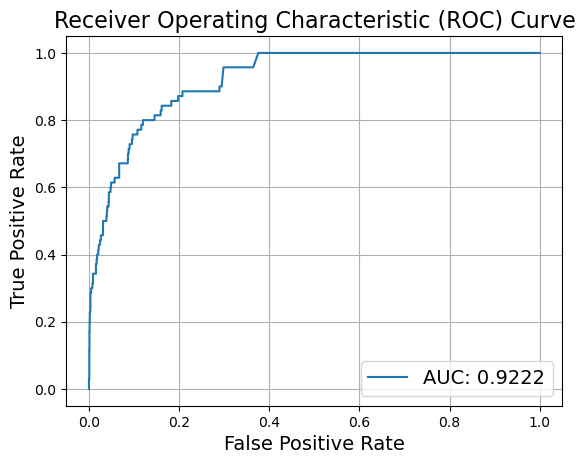

In [13]:
# usual split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# tokens into numerical features
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# TF-IDF scaling
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

# Train a Classifier (Multinomial Naive Bayes)
classifier = MultinomialNB()
classifier.fit(X_train_tfidf, y_train)

# Evaluate the Model - AUC and ROC curve
probs = classifier.predict_proba(X_test_tfidf)[:,1]
auc = roc_auc_score([int(i) for i in y_test], probs)
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f"AUC: {auc:.4f}")
plt.xlabel('False Positive Rate',fontsize=14)
plt.ylabel('True Positive Rate',fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve',fontsize=16)
plt.legend(fontsize=14)
plt.grid()
plt.show()


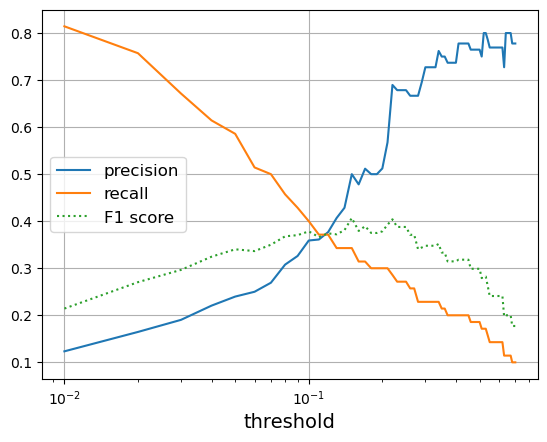

In [14]:
## Precision vs recall (vs threshold)
L = []
for th in np.arange(.01,.71,.01):
    y_pred = probs > th
    cm = confusion_matrix(y_test,y_pred)
    fp = cm[0,1]
    tp = cm[1,1]
    fn = cm[1,0]
    F = 2*tp/(2*tp+fp+fn)
    L.append([th, fp, tp, fn, tp/(tp+fp), tp/(tp+fn), F])

_df = pd.DataFrame(L, columns=['weight','fp','tp','fn','precision','recall','F1'])
plt.semilogx(_df.weight, _df.precision, label='precision')
plt.semilogx(_df.weight, _df.recall, label='recall')
plt.semilogx(_df.weight, _df.F1, label='F1 score', ls=':')
plt.grid()
plt.xlabel('threshold', fontsize=14)
plt.legend(fontsize=12);


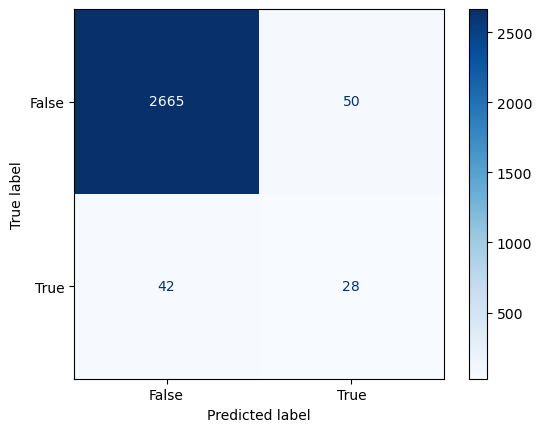

In [15]:
## Confusion matrix for a given threshold
y_pred = probs>.1
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classifier.classes_)
disp.plot(cmap="Blues")
plt.show()


## EDA

In [16]:
df_motifs.head()


,tree,root,size,pattern,type,time,bad,process,pattern_plus,anonymized_pattern_plus
0,0,39,2,ssm-document-worker.exe::wmic.exe,edge,0.157027,False,ssm-document-worker.exe,ssm-document-worker.exe::wmic.exe_edge,root::wmic.exe_edge
1,0,39,3,ssm-document-worker.exe::wmic.exe::wmic.exe,balanced,0.259217,False,ssm-document-worker.exe,ssm-document-worker.exe::wmic.exe::wmic.exe_ba...,root::wmic.exe::wmic.exe_balanced
2,0,39,4,ssm-document-worker.exe::wmic.exe::wmic.exe::w...,star,0.157027,False,ssm-document-worker.exe,ssm-document-worker.exe::wmic.exe::wmic.exe::w...,root::wmic.exe::wmic.exe::wmic.exe_star
3,0,39,3,ssm-document-worker.exe::wmic.exe::wmic.exe,balanced,0.157027,False,ssm-document-worker.exe,ssm-document-worker.exe::wmic.exe::wmic.exe_ba...,root::wmic.exe::wmic.exe_balanced
4,0,39,2,ssm-document-worker.exe::wmic.exe,edge,0.259217,False,ssm-document-worker.exe,ssm-document-worker.exe::wmic.exe_edge,root::wmic.exe_edge


In [17]:
mc = set([x[0] for x in Counter(process).most_common(top_process)])
_df = df_motifs[ (df_motifs['process'].isin(mc)) & (df_motifs['size']==4) ]
ct = pd.crosstab(_df['process'],_df['type'])

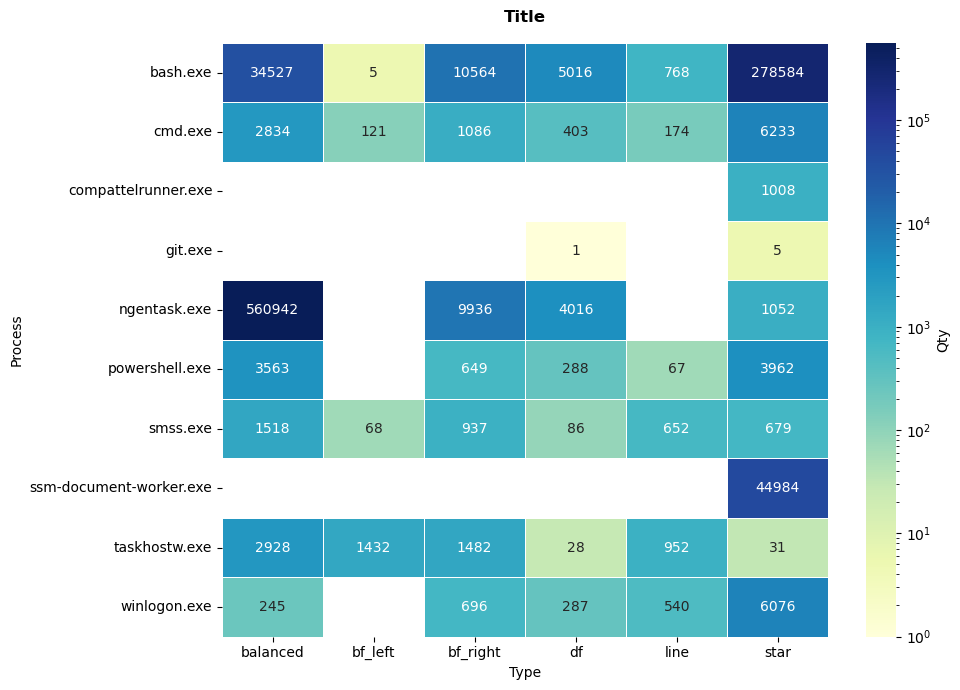

In [18]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(10, 7))

sns.heatmap(
    ct,
    annot=True,  # Affiche les valeurs numériques dans les cases
    fmt=".0f",  # Format des nombres (pas de décimale)
    cmap="YlGnBu",  # Palette de couleurs (Jaune -> Vert -> Bleu)
    linewidths=0.5,  # Ajoute une fine ligne de séparation entre les cases
    norm=LogNorm(),  # <--- Applique l'échelle logarithmique pour les couleurs
    vmin=1,  # <--- Force le minimum à 1 pour gérer proprement la valeur 0
    cbar_kws={"label": "Qty"},  # Légende de la barre de couleur
)

plt.title(
    "Title",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Type", fontsize=10)
plt.ylabel("Process", fontsize=10)

plt.tight_layout()
plt.show()

In [19]:
mc = set([x[0] for x in Counter(process).most_common(top_process)])
_df = df_motifs[ (df_motifs['process'].isin(mc)) & (df_motifs['size']==4) & (df_motifs['bad']==True) ]
ctb = pd.crosstab(_df['process'],_df['type'])


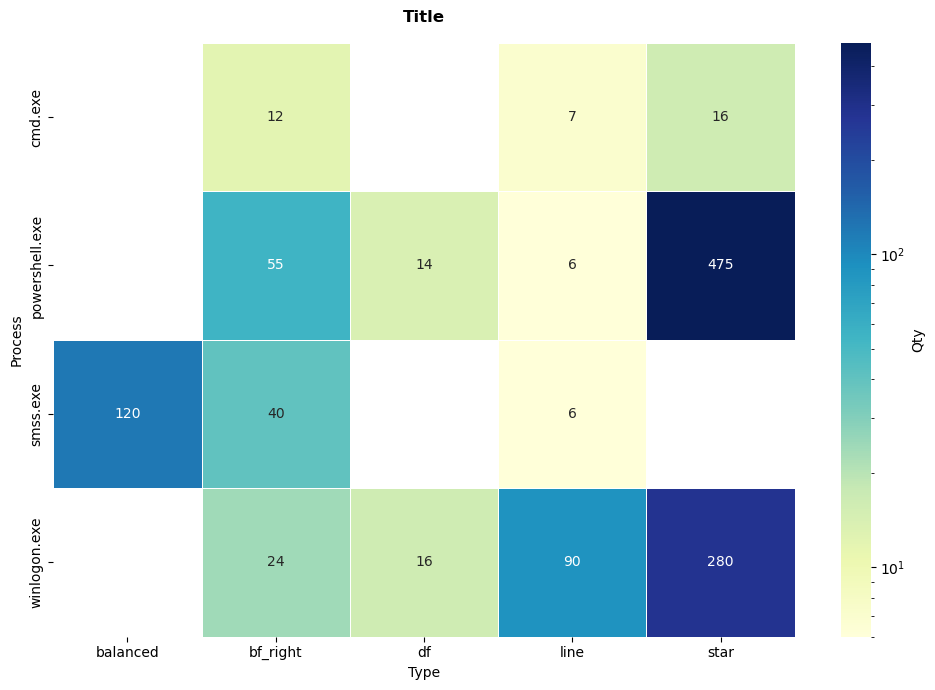

In [20]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    ctb,
    annot=True,  # Affiche les valeurs numériques dans les cases
    fmt=".0f",  # Format des nombres (pas de décimale)
    cmap="YlGnBu",  # Palette de couleurs (Jaune -> Vert -> Bleu)
    linewidths=0.5,  # Ajoute une fine ligne de séparation entre les cases
    norm=LogNorm(),  # <--- Applique l'échelle logarithmique pour les couleurs
    vmin=1,  # <--- Force le minimum à 1 pour gérer proprement la valeur 0
    cbar_kws={"label": "Qty"},  # Légende de la barre de couleur
)

plt.title(
    "Title",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Type", fontsize=10)
plt.ylabel("Process", fontsize=10)

plt.tight_layout()
plt.show()